# Mô hình dự đoán `is_canceled` — LightGBM v2.1

Phiên bản **v2.1** cải tiến từ **v2**, giữ pipeline LightGBM + feature engineering v1.2, với các thay đổi:

| Cải tiến | v2 | **v2.1** |
|----------|----|----------|
| Ngưỡng dự đoán | 0,35 | **0,28** (ưu tiên Recall Hủy) |
| Cân bằng lớp | `class_weight='balanced'` | **`scale_pos_weight` tăng** (×1,5 so tỷ lệ tự nhiên) |
| Mùa vụ | chỉ `arrival_month_mapped` (1–12) | **+ `arrival_season`** (Spring/Summer/Autumn/Winter) |
| Artifact | không lưu | **Lưu `best_params` → JSON** (tắt tuning khi inference) |

### Nhóm 1 — Mức độ cam kết tài chính (Financial Commitment)
| Biến | Công thức |
|------|----------|
| `total_guests` | `adults + children + babies` |
| `price_per_person` | `adr / total_guests` |
| `is_family` | 1 nếu `children > 0` hoặc `babies > 0`, ngược lại 0 |

### Nhóm 2 — Cấu trúc chuyến đi (Trip Structure)
| Biến | Công thức |
|------|----------|
| `total_nights` | `stays_in_weekend_nights + stays_in_week_nights` |
| `lead_time_per_night` | `lead_time / total_nights` |

### Nhóm 3 — Lịch sử và uy tín (Trust & History)
| Biến | Công thức |
|------|----------|
| `history_cancel_rate` | `previous_cancellations / (previous_cancellations + previous_bookings_not_canceled)` |

### Nhóm 4 — Lịch & mùa (Calendar & Seasonality)
| Biến | Công thức |
|------|----------|
| `is_weekend_only` | 1 nếu chỉ ở cuối tuần (`weekend_nights > 0` và `week_nights == 0`) |
| `arrival_month_mapped` | Tháng đến ánh xạ số 1–12 (Jan→1 … Dec→12) |
| `arrival_season` | Tách từ tháng: Winter (12–2), Spring (3–5), Summer (6–8), Autumn (9–11) |

Giữ nguyên 6 biến phân loại v1.1 + `lead_time`, `total_of_special_requests`.

**Ngưỡng dự đoán:** `P(hủy) >= 0.28` → dự đoán **Hủy**.

**Nguyên tắc chống Data Leakage:**
1. Chỉ đọc feature + target cần thiết — **không** nạp `reservation_status`, `revenue`, `Occupancy_Rate`, `RevPAR`, ...
2. Feature engineering chỉ dùng thông tin có tại thời điểm đặt phòng.
3. `train_test_split` **trước** mọi bước tiền xử lý mã hóa.
4. `OneHotEncoder` chỉ `fit` trên tập train (qua `Pipeline` + `ColumnTransformer`).
5. `scale_pos_weight` tính **chỉ từ `y_train`**.


In [31]:
import json
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
TEST_SIZE = 0.2
DATA_BASENAME = "hotel_bookings"
VERSION_PATTERN = re.compile(rf"^{DATA_BASENAME}_v(\d+)\.csv$", re.IGNORECASE)

LEAKAGE_COLUMNS = {
    "reservation_status",
    "reservation_status_date",
    "revenue",
    "Occupancy_Rate",
    "RevPAR",
}

# v2.1: hạ ngưỡng để tăng Recall Hủy (khuyến nghị báo cáo v2)
PREDICTION_THRESHOLD = 0.28

# v2.1: tăng scale_pos_weight so với tỷ lệ tự nhiên n_neg/n_pos
SCALE_POS_WEIGHT_MULTIPLIER = 1.5

MONTH_ORDER = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
MONTH_TO_NUM = {month: i + 1 for i, month in enumerate(MONTH_ORDER)}

# Winter: Dec–Feb | Spring: Mar–May | Summer: Jun–Aug | Autumn: Sep–Nov
MONTH_TO_SEASON = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
}

CATEGORICAL_FEATURES = [
    "deposit_type",
    "market_segment",
    "country",
    "distribution_channel",
    "customer_type",
    "hotel",
    "arrival_season",  # v2.1: tách mùa từ arrival_month_mapped
]

RAW_COLUMNS_FOR_ENGINEERING = [
    "adults", "children", "babies", "adr",
    "stays_in_weekend_nights", "stays_in_week_nights",
    "previous_bookings_not_canceled", "arrival_date_month",
]

NUMERIC_FEATURES = [
    "lead_time",
    "total_of_special_requests",
    "total_guests",
    "price_per_person",
    "is_family",
    "total_nights",
    "lead_time_per_night",
    "history_cancel_rate",
    "is_weekend_only",
    "arrival_month_mapped",
]
FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERIC_FEATURES
TARGET_COLUMN = "is_canceled"


def _data_search_roots() -> list[Path]:
    notebook_dir = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
    search_roots = [
        notebook_dir / "data",
        notebook_dir,
        notebook_dir.parent / "data",
        notebook_dir.parent,
        notebook_dir.parent.parent,
        Path.cwd() / "data",
        Path.cwd(),
    ]
    path = Path.cwd()
    for _ in range(6):
        search_roots.extend([path / "data", path])
        path = path.parent

    seen, roots = set(), []
    for root in search_roots:
        try:
            root = root.resolve()
        except OSError:
            continue
        if root not in seen:
            seen.add(root)
            roots.append(root)
    return roots


def find_latest_versioned_data_file() -> Path:
    candidates: list[tuple[int, Path]] = []
    for root in _data_search_roots():
        if not root.is_dir():
            continue
        for file_path in root.glob(f"{DATA_BASENAME}_v*.csv"):
            if "test" in file_path.name.lower():
                continue
            match = VERSION_PATTERN.match(file_path.name)
            if match:
                candidates.append((int(match.group(1)), file_path.resolve()))

    if not candidates:
        raise FileNotFoundError(f"Không tìm thấy file '{DATA_BASENAME}_v*.csv'")

    latest_version, latest_path = max(candidates, key=lambda item: item[0])
    print(f"Chọn file v{latest_version} mới nhất: {latest_path.name}")
    return latest_path


def _resolve_artifact_dir() -> Path:
    """Ưu tiên thư mục chứa notebook v2/v2.1, fallback cwd/artifacts."""
    candidates: list[Path] = []
    cwd = Path.cwd().resolve()
    for root in _data_search_roots():
        for name in ("09_cancellation_model_v2_1.ipynb", "09_cancellation_model_v2.ipynb"):
            hit = root / name
            if hit.exists():
                candidates.append(hit.parent / "artifacts")
            nested = root / "models" / "Cancellation Predict Model v2" / name
            if nested.exists():
                candidates.append(nested.parent / "artifacts")
    candidates.extend([
        cwd / "artifacts",
        cwd / "models" / "Cancellation Predict Model v2" / "artifacts",
    ])
    seen = set()
    for path in candidates:
        key = str(path)
        if key in seen:
            continue
        seen.add(key)
        try:
            return path
        except OSError:
            continue
    return cwd / "artifacts"


ARTIFACT_DIR = _resolve_artifact_dir()
BEST_PARAMS_PATH = ARTIFACT_DIR / "best_params_v2_1.json"
DRAFT_PARAMS_PATH = ARTIFACT_DIR / "best_params_v2_1_draft.json"
print(f"Artifact dir: {ARTIFACT_DIR}")
print(f"Production params: {BEST_PARAMS_PATH.name}")
print(f"Draft params:      {DRAFT_PARAMS_PATH.name}")

csv_path = find_latest_versioned_data_file()
print(f"Đang đọc: {csv_path}")

read_columns = list(
    dict.fromkeys(
        [c for c in CATEGORICAL_FEATURES if c != "arrival_season"]
        + ["lead_time", "total_of_special_requests"]
        + RAW_COLUMNS_FOR_ENGINEERING
        + ["previous_cancellations"]
        + [TARGET_COLUMN]
    )
)
df = pd.read_csv(csv_path, usecols=read_columns)

print(f"Số booking: {len(df):,}")
print(f"Tỷ lệ hủy: {df[TARGET_COLUMN].mean() * 100:.2f}%")
print(f"Ngưỡng dự đoán v2.1: {PREDICTION_THRESHOLD}")
print(f"\nCột leakage đã loại: {sorted(LEAKAGE_COLUMNS)}")
df.head()


Artifact dir: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\models\Cancellation Predict Model v2\artifacts
Production params: best_params_v2_1.json
Draft params:      best_params_v2_1_draft.json
Chọn file v5 mới nhất: hotel_bookings_v5.csv
Đang đọc: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
Số booking: 82,811
Tỷ lệ hủy: 28.12%
Ngưỡng dự đoán v2.1: 0.28

Cột leakage đã loại: ['Occupancy_Rate', 'RevPAR', 'reservation_status', 'reservation_status_date', 'revenue']


,hotel,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,country,market_segment,distribution_channel,previous_cancellations,previous_bookings_not_canceled,deposit_type,customer_type,adr,total_of_special_requests
0,Resort Hotel,0,342,July,0,0,2,0,0,PRT,Direct,Direct,0,0,No Deposit,Transient,0.0,0
1,Resort Hotel,0,737,July,0,0,2,0,0,PRT,Direct,Direct,0,0,No Deposit,Transient,0.0,0
2,Resort Hotel,0,7,July,0,1,1,0,0,GBR,Direct,Direct,0,0,No Deposit,Transient,75.0,0
3,Resort Hotel,0,13,July,0,1,1,0,0,GBR,Corporate,Corporate,0,0,No Deposit,Transient,75.0,0
4,Resort Hotel,0,14,July,0,2,2,0,0,GBR,Online TA,TA/TO,0,0,No Deposit,Transient,98.0,1


## 1. Feature engineering & kiểm tra dữ liệu

Tạo biến engineered (v1.2 + **`arrival_season`** từ tháng), xử lý edge case (chia cho 0), rồi chuẩn bị ma trận `X`.


In [32]:
def engineer_features(raw: pd.DataFrame) -> pd.DataFrame:
    """Tạo biến engineered v2.1 từ cột thô (thông tin có tại thời điểm đặt)."""
    out = raw.copy()

    out["children"] = out["children"].fillna(0)
    out["total_guests"] = out["adults"] + out["children"] + out["babies"]
    out["total_guests"] = out["total_guests"].clip(lower=1)

    out["price_per_person"] = out["adr"] / out["total_guests"]
    out["is_family"] = (
        (out["children"] > 0) | (out["babies"] > 0)
    ).astype(int)

    out["total_nights"] = (
        out["stays_in_weekend_nights"] + out["stays_in_week_nights"]
    )
    out["lead_time_per_night"] = out["lead_time"] / out["total_nights"].clip(lower=1)

    prior_total = (
        out["previous_cancellations"] + out["previous_bookings_not_canceled"]
    )
    out["history_cancel_rate"] = np.where(
        prior_total > 0,
        out["previous_cancellations"] / prior_total,
        0.0,
    )

    out["is_weekend_only"] = (
        (out["stays_in_weekend_nights"] > 0) & (out["stays_in_week_nights"] == 0)
    ).astype(int)

    out["arrival_month_mapped"] = (
        out["arrival_date_month"].map(MONTH_TO_NUM).fillna(0).astype(int)
    )
    # v2.1: tách tháng thành mùa
    out["arrival_season"] = (
        out["arrival_month_mapped"].map(MONTH_TO_SEASON).fillna("Unknown")
    )

    return out


print("=== Missing values (cột thô) ===")
print(df[RAW_COLUMNS_FOR_ENGINEERING + ["previous_cancellations"]].isna().sum())

engineered_df = engineer_features(df)

print("\n=== Biến engineered (describe) ===")
engineered_cols = [
    "total_guests", "price_per_person", "is_family",
    "total_nights", "lead_time_per_night", "history_cancel_rate",
    "is_weekend_only", "arrival_month_mapped",
]
display(engineered_df[engineered_cols].describe().T)

print("\n=== Phân bố arrival_season ===")
display(
    engineered_df["arrival_season"]
    .value_counts()
    .rename_axis("arrival_season")
    .reset_index(name="n")
)

model_df = engineered_df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
model_df["country"] = model_df["country"].fillna("Unknown").astype(str)
for col in CATEGORICAL_FEATURES:
    model_df[col] = model_df[col].astype(str)

int_like = [
    "lead_time", "total_of_special_requests", "total_guests", "is_family",
    "total_nights", "is_weekend_only", "arrival_month_mapped",
]
float_like = ["price_per_person", "lead_time_per_night", "history_cancel_rate"]
for col in int_like:
    model_df[col] = model_df[col].fillna(0).astype(int)
for col in float_like:
    model_df[col] = model_df[col].fillna(0.0).astype(float)

X = model_df[FEATURE_COLUMNS]
y = model_df[TARGET_COLUMN].astype(int)

print(f"\nKích thước X: {X.shape} ({len(CATEGORICAL_FEATURES)} phân loại + {len(NUMERIC_FEATURES)} số)")
print(f"Phân bố y: {y.value_counts().to_dict()}")


=== Missing values (cột thô) ===
adults                            0
children                          0
babies                            0
adr                               0
stays_in_weekend_nights           0
stays_in_week_nights              0
previous_bookings_not_canceled    0
arrival_date_month                0
previous_cancellations            0
dtype: int64

=== Biến engineered (describe) ===


,count,mean,std,min,25%,50%,75%,max
total_guests,82811.0,2.044861,0.797066,1.00,2.00,2.000000,2.0,55.0
price_per_person,82811.0,55.694585,29.939480,-3.19,38.00,50.000000,67.5,2700.0
is_family,82811.0,0.108585,0.311119,0.00,0.00,0.000000,0.0,1.0
total_nights,82811.0,3.674705,2.786843,0.00,2.00,3.000000,5.0,69.0
lead_time_per_night,82811.0,25.199919,36.216372,0.00,4.25,14.428571,32.0,737.0
history_cancel_rate,82811.0,0.013364,0.110402,0.00,0.00,0.000000,0.0,1.0
is_weekend_only,82811.0,0.062902,0.242789,0.00,0.00,0.000000,0.0,1.0
arrival_month_mapped,82811.0,6.467390,3.088011,1.00,4.00,7.000000,9.0,12.0



=== Phân bố arrival_season ===


,arrival_season,n
0,Summer,28072
1,Spring,22466
2,Autumn,17204
3,Winter,15069



Kích thước X: (82811, 17) (7 phân loại + 10 số)
Phân bố y: {0: 59527, 1: 23284}


## 2. Train / Test split (trước khi mã hóa)

Tách dữ liệu **trước** mọi bước fit encoder để tránh leakage từ tập test vào quá trình học category. `scale_pos_weight` cũng chỉ tính từ `y_train`.


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
SCALE_POS_WEIGHT_BASE = n_neg / n_pos
SCALE_POS_WEIGHT = SCALE_POS_WEIGHT_BASE * SCALE_POS_WEIGHT_MULTIPLIER

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Tỷ lệ hủy train: {y_train.mean() * 100:.2f}%")
print(f"Tỷ lệ hủy test:  {y_test.mean() * 100:.2f}%")
print(f"\nscale_pos_weight base (n_neg/n_pos): {SCALE_POS_WEIGHT_BASE:.4f}")
print(f"scale_pos_weight × {SCALE_POS_WEIGHT_MULTIPLIER}: {SCALE_POS_WEIGHT:.4f}")


Train: 66,248 | Test: 16,563
Tỷ lệ hủy train: 28.12%
Tỷ lệ hủy test:  28.12%

scale_pos_weight base (n_neg/n_pos): 2.5566
scale_pos_weight × 1.5: 3.8348


## 3. Pipeline: One-Hot + biến số → LightGBM

- **OneHotEncoder** cho biến phân loại (gồm `arrival_season`); biến số đi **passthrough**.
- `min_frequency=5`: gộp category hiếm thành `infrequent` — chỉ học từ train.
- **LightGBM**: dùng **`scale_pos_weight` tăng** (thay `class_weight='balanced'`) để ưu tiên class Hủy.
- Dự đoán nhị phân dùng ngưỡng **0,28**: `y_pred = (P(hủy) >= 0.28)`.


In [34]:
BASELINE_LGBM_PARAMS = {
    "n_estimators": 300,
    "max_depth": 12,
    "min_child_samples": 20,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": SCALE_POS_WEIGHT,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}

RUN_TUNING = False
TUNING_CV = 3
N_OPTUNA_TRIALS = 50
# Đổi seed khi muốn Optuna khám phá vùng tham số khác (cùng seed → kết quả gần như lặp lại)
TUNING_SEED = RANDOM_STATE


def make_lgbm_pipeline(**classifier_kwargs) -> Pipeline:
    """Tạo Pipeline One-Hot + LightGBM với tham số classifier tùy chỉnh."""
    cat_encoder = OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=5,
        sparse_output=False,
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", cat_encoder, CATEGORICAL_FEATURES),
            ("num", "passthrough", NUMERIC_FEATURES),
        ],
        remainder="drop",
    )
    params = {**BASELINE_LGBM_PARAMS, **classifier_kwargs}
    # Không dùng đồng thời class_weight và scale_pos_weight
    params.pop("class_weight", None)
    params.setdefault("scale_pos_weight", SCALE_POS_WEIGHT)
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LGBMClassifier(**params)),
        ]
    )


def metrics_at_threshold(y_true, y_proba, threshold=PREDICTION_THRESHOLD) -> dict:
    y_hat = (y_proba >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "recall_huy": recall_score(y_true, y_hat, pos_label=1),
        "precision_huy": precision_score(y_true, y_hat, pos_label=1),
        "f1_huy": f1_score(y_true, y_hat, pos_label=1),
        "accuracy": (y_hat == y_true).mean(),
    }


def _serialize_param_value(v):
    if isinstance(v, (np.floating, float)):
        return float(v)
    if isinstance(v, (np.integer, int)) and not isinstance(v, bool):
        return int(v)
    return v


def save_params_artifact(
    params: dict,
    path: Path,
    *,
    cv_roc_auc: float | None = None,
    tuning_source: str | None = None,
    note: str | None = None,
) -> Path:
    """Lưu artifact JSON (production hoặc draft) kèm metadata so sánh."""
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "cv_roc_auc": None if cv_roc_auc is None else float(cv_roc_auc),
        "tuning_source": tuning_source,
        "prediction_threshold": PREDICTION_THRESHOLD,
        "scale_pos_weight": float(SCALE_POS_WEIGHT),
        "note": note,
        "params": {k: _serialize_param_value(v) for k, v in params.items()},
    }
    path.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"Đã lưu artifact → {path}")
    return path


def load_params_artifact(path: Path = BEST_PARAMS_PATH) -> dict | None:
    """Nạp artifact. Hỗ trợ format mới {params, cv_roc_auc, ...} và format cũ (flat)."""
    if not path.exists():
        return None
    raw = json.loads(path.read_text(encoding="utf-8"))
    if isinstance(raw, dict) and "params" in raw and isinstance(raw["params"], dict):
        return raw
    # Legacy: toàn bộ file là dict params
    return {
        "cv_roc_auc": None,
        "tuning_source": "legacy_flat",
        "prediction_threshold": PREDICTION_THRESHOLD,
        "scale_pos_weight": raw.get("scale_pos_weight"),
        "note": "loaded from flat best_params format",
        "params": raw,
    }


def load_best_params(path: Path = BEST_PARAMS_PATH) -> dict | None:
    """Trả về dict params thuần (tương thích code cũ)."""
    artifact = load_params_artifact(path)
    return None if artifact is None else artifact["params"]


def save_best_params(params: dict, path: Path = BEST_PARAMS_PATH, **kwargs) -> Path:
    """Alias: lưu production artifact."""
    return save_params_artifact(params, path, **kwargs)


lgbm_baseline_pipeline = make_lgbm_pipeline()
lgbm_pipeline = lgbm_baseline_pipeline
lgbm_baseline_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 3b. Tinh chỉnh hyperparameter (GridSearchCV + Optuna)

Tìm bộ tham số tốt nhất **chỉ trên tập train** (CV), tránh leakage từ test.

- **GridSearchCV:** lưới tham số cố định, tối ưu `roc_auc`.
- **Optuna (TPE):** tìm kiếm rộng hơn (`num_leaves`, `reg_alpha`, `reg_lambda`, ...).
- Chọn phương án có **CV ROC-AUC cao hơn** trong lần chạy hiện tại.
- **An toàn artifact:** luôn ghi ứng viên vào `artifacts/best_params_v2_1_draft.json`. Chỉ **promote** sang `best_params_v2_1.json` khi CV ROC-AUC **tốt hơn** bản production hiện có.
- Khi `RUN_TUNING=False`: nạp production (không tune). Đổi `TUNING_SEED` / `N_OPTUNA_TRIALS` nếu muốn Optuna khám phá vùng khác.


In [35]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

try:
    import optuna
    from optuna.samplers import TPESampler
except ImportError:
    raise ImportError("Cài optuna: pip install optuna")

cv_tune = StratifiedKFold(n_splits=TUNING_CV, shuffle=True, random_state=RANDOM_STATE)

FIXED_LGBM_META = {
    "scale_pos_weight": SCALE_POS_WEIGHT,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}


def _cv_roc_auc_of_params(params: dict) -> float:
    """Đánh giá CV ROC-AUC của một bộ params trên train (cùng fold tuning)."""
    pipe = make_lgbm_pipeline(**params)
    scores = cross_val_score(
        pipe, X_train, y_train, cv=cv_tune, scoring="roc_auc", n_jobs=-1,
    )
    return float(scores.mean())


def _resolve_production_cv_auc(prod_artifact: dict | None) -> float | None:
    """Lấy CV AUC production đã lưu; nếu thiếu thì đo lại từ params production."""
    if prod_artifact is None:
        return None
    stored = prod_artifact.get("cv_roc_auc")
    if stored is not None:
        return float(stored)
    prod_params = {**prod_artifact["params"], **FIXED_LGBM_META}
    prod_params["scale_pos_weight"] = SCALE_POS_WEIGHT
    print("Production chưa có cv_roc_auc — đang đo lại CV trên train...")
    measured = _cv_roc_auc_of_params(prod_params)
    print(f"Production CV ROC-AUC (đo lại): {measured:.4f}")
    return measured


promoted_to_production = False
candidate_cv_auc = None
production_cv_auc = None

if not RUN_TUNING:
    loaded_artifact = load_params_artifact(BEST_PARAMS_PATH)
    if loaded_artifact is not None:
        best_params = {**loaded_artifact["params"], **FIXED_LGBM_META}
        best_params["scale_pos_weight"] = SCALE_POS_WEIGHT
        tuning_source = f"loaded ({BEST_PARAMS_PATH.name})"
        production_cv_auc = loaded_artifact.get("cv_roc_auc")
        print(f"Bỏ qua tuning — nạp best_params từ {BEST_PARAMS_PATH}")
        if production_cv_auc is not None:
            print(f"Production CV ROC-AUC (đã lưu): {float(production_cv_auc):.4f}")
    else:
        best_params = BASELINE_LGBM_PARAMS.copy()
        tuning_source = "baseline (RUN_TUNING=False, chưa có artifact)"
        print("Bỏ qua tuning — dùng BASELINE_LGBM_PARAMS (chưa có file best_params).")
    grid_cv_auc = optuna_cv_auc = None
else:
    print("=== GridSearchCV (scoring=roc_auc) ===")
    param_grid = {
        "classifier__n_estimators": [250, 400],
        "classifier__max_depth": [10, 14],
        "classifier__min_child_samples": [15, 30],
        "classifier__learning_rate": [0.03, 0.06],
        "classifier__subsample": [0.75, 0.85],
        "classifier__colsample_bytree": [0.75, 0.85],
    }
    grid_search = GridSearchCV(
        estimator=make_lgbm_pipeline(),
        param_grid=param_grid,
        cv=cv_tune,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1,
    )
    grid_search.fit(X_train, y_train)
    grid_cv_auc = grid_search.best_score_
    grid_best_params = {
        k.replace("classifier__", ""): v for k, v in grid_search.best_params_.items()
    }
    print(f"GridSearch best CV ROC-AUC: {grid_cv_auc:.4f}")
    print("GridSearch best params:", grid_best_params)

    print(f"\n=== Optuna TPE ({N_OPTUNA_TRIALS} trials, seed={TUNING_SEED}, scoring=roc_auc) ===")
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def optuna_objective(trial: optuna.Trial) -> float:
        trial_params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 500, step=50),
            "max_depth": trial.suggest_int("max_depth", 6, 16),
            "num_leaves": trial.suggest_int("num_leaves", 20, 80),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 50, step=5),
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.1, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 0.95),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.95),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        }
        pipe = make_lgbm_pipeline(**trial_params)
        scores = cross_val_score(
            pipe, X_train, y_train, cv=cv_tune, scoring="roc_auc", n_jobs=-1,
        )
        return float(scores.mean())

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=TUNING_SEED),
    )
    study.optimize(optuna_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)
    optuna_cv_auc = study.best_value
    optuna_best_params = study.best_params
    print(f"Optuna best CV ROC-AUC: {optuna_cv_auc:.4f}")
    print("Optuna best params:", optuna_best_params)

    if optuna_cv_auc >= grid_cv_auc:
        candidate_params = {**optuna_best_params, **FIXED_LGBM_META}
        candidate_source = "Optuna"
        candidate_cv_auc = float(optuna_cv_auc)
    else:
        candidate_params = {**grid_best_params, **FIXED_LGBM_META}
        candidate_source = "GridSearchCV"
        candidate_cv_auc = float(grid_cv_auc)

    print(f"\n>>> Ứng viên lần chạy này: {candidate_source} | CV ROC-AUC = {candidate_cv_auc:.4f}")

    # 1) Luôn ghi nháp — không đụng production ngay
    save_params_artifact(
        candidate_params,
        DRAFT_PARAMS_PATH,
        cv_roc_auc=candidate_cv_auc,
        tuning_source=candidate_source,
        note=f"draft run | TUNING_SEED={TUNING_SEED} | N_OPTUNA_TRIALS={N_OPTUNA_TRIALS}",
    )

    # 2) So với production — chỉ promote nếu tốt hơn
    prod_artifact = load_params_artifact(BEST_PARAMS_PATH)
    production_cv_auc = _resolve_production_cv_auc(prod_artifact)

    if production_cv_auc is None:
        save_params_artifact(
            candidate_params,
            BEST_PARAMS_PATH,
            cv_roc_auc=candidate_cv_auc,
            tuning_source=candidate_source,
            note="first production save from draft",
        )
        promoted_to_production = True
        print(
            f">>> Chưa có production — đã promote draft → {BEST_PARAMS_PATH.name} "
            f"(CV={candidate_cv_auc:.4f})"
        )
    elif candidate_cv_auc > production_cv_auc:
        save_params_artifact(
            candidate_params,
            BEST_PARAMS_PATH,
            cv_roc_auc=candidate_cv_auc,
            tuning_source=candidate_source,
            note=(
                f"promoted from draft | prev_cv={production_cv_auc:.6f} "
                f"→ new_cv={candidate_cv_auc:.6f}"
            ),
        )
        promoted_to_production = True
        print(
            f">>> TỐT HƠN production ({candidate_cv_auc:.4f} > {production_cv_auc:.4f}) "
            f"— đã cập nhật {BEST_PARAMS_PATH.name}"
        )
    else:
        print(
            f">>> Không tốt hơn production ({candidate_cv_auc:.4f} ≤ {production_cv_auc:.4f}) "
            f"— giữ nguyên {BEST_PARAMS_PATH.name}; draft vẫn ở {DRAFT_PARAMS_PATH.name}"
        )

    # Notebook dùng ứng viên vừa tune để bạn xem kết quả lần chạy này
    best_params = candidate_params
    tuning_source = f"{candidate_source} (draft)"
    if promoted_to_production:
        tuning_source = f"{candidate_source} (promoted)"

lgbm_pipeline = make_lgbm_pipeline(**best_params)

if RUN_TUNING:
    compare_cv = pd.DataFrame(
        {
            "phương_pháp": ["Baseline", "GridSearchCV", "Optuna", "Production (lưu)"],
            "cv_roc_auc": [
                cross_val_score(
                    lgbm_baseline_pipeline, X_train, y_train,
                    cv=cv_tune, scoring="roc_auc", n_jobs=-1,
                ).mean(),
                grid_cv_auc,
                optuna_cv_auc,
                production_cv_auc if not promoted_to_production else candidate_cv_auc,
            ],
        }
    ).round(4)
    print("\n=== So sánh CV ROC-AUC (cùng fold) ===")
    display(compare_cv)
    print(
        f"Promote production: {promoted_to_production} | "
        f"draft={DRAFT_PARAMS_PATH.name} | prod={BEST_PARAMS_PATH.name}"
    )
else:
    print("\n=== Bỏ qua bảng so sánh CV (RUN_TUNING=False) ===")

print("\n=== Best params (dùng cho lgbm_pipeline lần chạy này) ===")
display(pd.Series(best_params, name="value"))
print(f"Production: {BEST_PARAMS_PATH} | exists={BEST_PARAMS_PATH.exists()}")
print(f"Draft:      {DRAFT_PARAMS_PATH} | exists={DRAFT_PARAMS_PATH.exists()}")


=== GridSearchCV (scoring=roc_auc) ===
Fitting 3 folds for each of 64 candidates, totalling 192 fits
GridSearch best CV ROC-AUC: 0.8626
GridSearch best params: {'colsample_bytree': 0.75, 'learning_rate': 0.06, 'max_depth': 14, 'min_child_samples': 15, 'n_estimators': 400, 'subsample': 0.75}

=== Optuna TPE (50 trials, seed=42, scoring=roc_auc) ===
Optuna best CV ROC-AUC: 0.8660
Optuna best params: {'n_estimators': 350, 'max_depth': 16, 'num_leaves': 74, 'min_child_samples': 50, 'learning_rate': 0.05580055120883812, 'subsample': 0.7246857661513708, 'colsample_bytree': 0.6009002719524649, 'reg_alpha': 0.0013403277773316451, 'reg_lambda': 0.006086076357515975}

>>> Ứng viên lần chạy này: Optuna | CV ROC-AUC = 0.8660
Đã lưu artifact → C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\models\Cancellation Predict Model v2\artifacts\best_params_v2_1_draft.json
Đã lưu artifact → C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Bookin

,phương_pháp,cv_roc_auc
0,Baseline,0.8613
1,GridSearchCV,0.8626
2,Optuna,0.8660
3,Production (lưu),0.8660


Promote production: True | draft=best_params_v2_1_draft.json | prod=best_params_v2_1.json

=== Best params (dùng cho lgbm_pipeline lần chạy này) ===


n_estimators         350.000000
max_depth             16.000000
num_leaves            74.000000
min_child_samples     50.000000
learning_rate          0.055801
subsample              0.724686
colsample_bytree       0.600900
reg_alpha              0.001340
reg_lambda             0.006086
scale_pos_weight       3.834837
random_state          42.000000
n_jobs                -1.000000
verbose               -1.000000
Name: value, dtype: float64

Production: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\models\Cancellation Predict Model v2\artifacts\best_params_v2_1.json | exists=True
Draft:      C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\models\Cancellation Predict Model v2\artifacts\best_params_v2_1_draft.json | exists=True


## 4. Huấn luyện & đánh giá (Baseline vs Tuned)


In [36]:
print("Huấn luyện baseline...")
lgbm_baseline_pipeline.fit(X_train, y_train)
baseline_proba = lgbm_baseline_pipeline.predict_proba(X_test)[:, 1]
baseline_metrics = metrics_at_threshold(y_test, baseline_proba)

print("Huấn luyện mô hình đã tune...")
lgbm_pipeline.fit(X_train, y_train)
y_proba = lgbm_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= PREDICTION_THRESHOLD).astype(int)
tuned_metrics = metrics_at_threshold(y_test, y_proba)

compare_test = pd.DataFrame(
    [baseline_metrics, tuned_metrics],
    index=["Baseline", f"Tuned ({tuning_source})"],
).round(4)
print(f"\n=== So sánh Test @ ngưỡng {PREDICTION_THRESHOLD} ===")
display(compare_test)

print(f"\n=== Classification Report — Tuned ({tuning_source}) ===")
print(classification_report(y_test, y_pred, target_names=["Không hủy", "Hủy"]))

roc_auc = tuned_metrics["roc_auc"]
print(f"ROC-AUC (test, tuned): {roc_auc:.4f}")

cv_scores = cross_val_score(
    lgbm_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)
print(f"CV ROC-AUC 5-fold (tuned, train): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

y_pred_035 = (y_proba >= 0.35).astype(int)
y_pred_050 = (y_proba >= 0.5).astype(int)
print(f"\n--- So sánh ngưỡng (tuned) ---")
print(f"Recall @ 0.50: {recall_score(y_test, y_pred_050, pos_label=1):.4f} | F1: {f1_score(y_test, y_pred_050, pos_label=1):.4f}")
print(f"Recall @ 0.35: {recall_score(y_test, y_pred_035, pos_label=1):.4f} | F1: {f1_score(y_test, y_pred_035, pos_label=1):.4f}")
print(f"Recall @ {PREDICTION_THRESHOLD}: {recall_score(y_test, y_pred, pos_label=1):.4f} | F1: {f1_score(y_test, y_pred, pos_label=1):.4f}")


Huấn luyện baseline...
Huấn luyện mô hình đã tune...

=== So sánh Test @ ngưỡng 0.28 ===


,roc_auc,recall_huy,precision_huy,f1_huy,accuracy
Baseline,0.8658,0.9620,0.4050,0.5700,0.5920
Tuned (Optuna (promoted)),0.8720,0.9517,0.4258,0.5884,0.6256



=== Classification Report — Tuned (Optuna (promoted)) ===
              precision    recall  f1-score   support

   Không hủy       0.96      0.50      0.66     11906
         Hủy       0.43      0.95      0.59      4657

    accuracy                           0.63     16563
   macro avg       0.69      0.72      0.62     16563
weighted avg       0.81      0.63      0.64     16563

ROC-AUC (test, tuned): 0.8720
CV ROC-AUC 5-fold (tuned, train): 0.8677 ± 0.0038

--- So sánh ngưỡng (tuned) ---
Recall @ 0.50: 0.8578 | F1: 0.6613
Recall @ 0.35: 0.9270 | F1: 0.6120
Recall @ 0.28: 0.9517 | F1: 0.5884


## 5. Confusion Matrix & ROC Curve


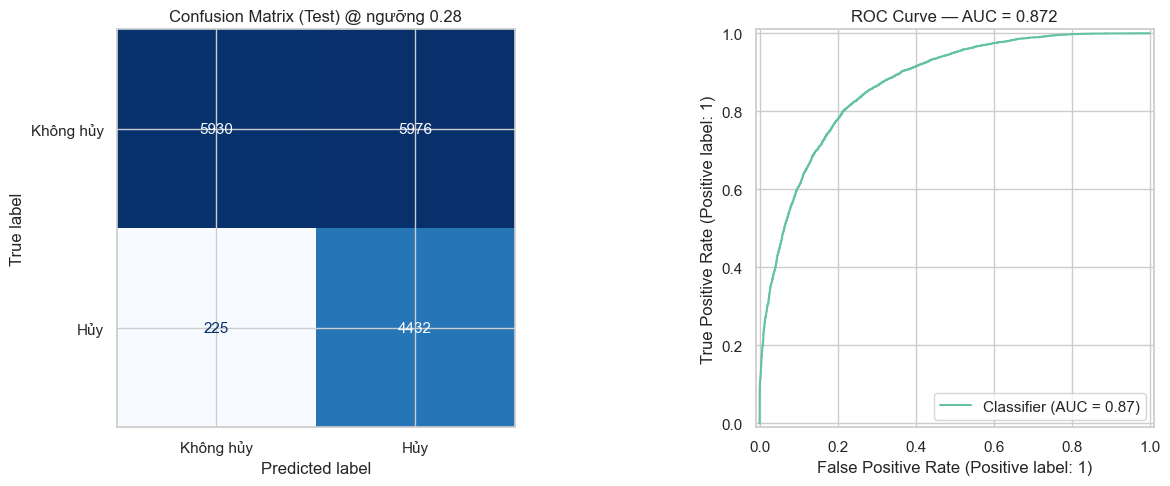

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Không hủy", "Hủy"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"Confusion Matrix (Test) @ ngưỡng {PREDICTION_THRESHOLD}")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f"ROC Curve — AUC = {roc_auc:.3f}")

plt.tight_layout()
plt.show()


## 6. Phân phối xác suất dự đoán

So sánh phân phối `P(hủy)` giữa booking thực sự hủy vs không hủy. Đường đứt nét = ngưỡng **0,28**.


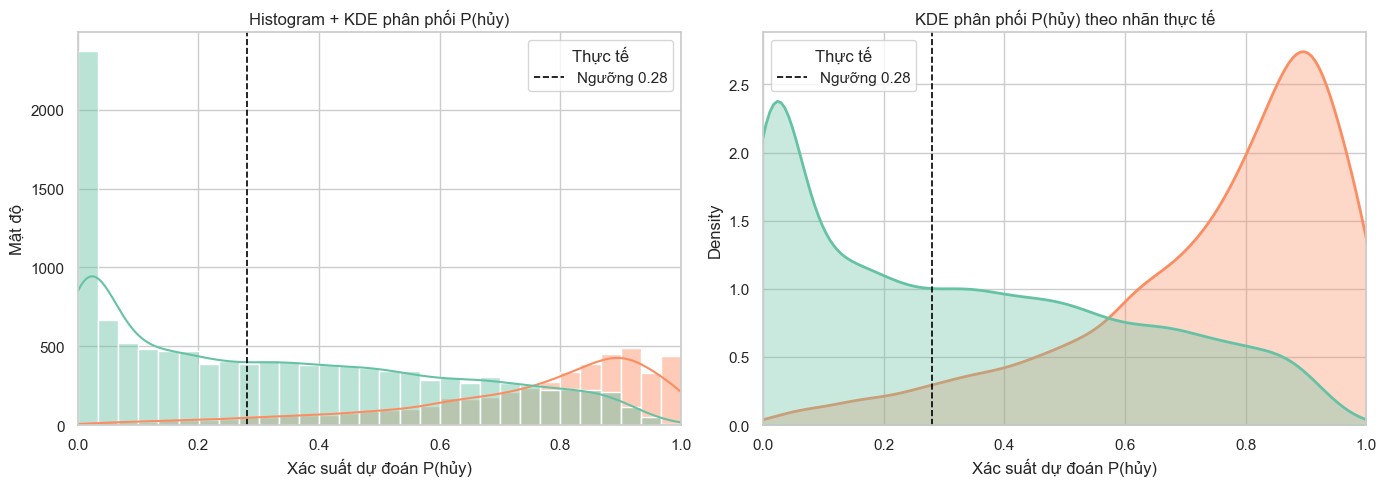

=== Thống kê P(hủy) theo nhãn thực tế (test) ===


,n,mean,median,std
actual,,,,
Không hủy,11906,0.3285,0.2824,0.2767
Hủy,4657,0.7458,0.8110,0.2158


In [38]:
proba_df = pd.DataFrame(
    {
        "probability": y_proba,
        "actual": np.where(y_test == 1, "Hủy", "Không hủy"),
    }
)

LABEL_ORDER = ["Không hủy", "Hủy"]
LABEL_PALETTE = {"Không hủy": "#66c2a5", "Hủy": "#fc8d62"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=proba_df,
    x="probability",
    hue="actual",
    hue_order=LABEL_ORDER,
    palette=LABEL_PALETTE,
    bins=30,
    kde=True,
    common_norm=False,
    alpha=0.45,
    ax=axes[0],
)
axes[0].axvline(PREDICTION_THRESHOLD, color="black", linestyle="--", linewidth=1.2, label=f"Ngưỡng {PREDICTION_THRESHOLD}")
axes[0].set_xlabel("Xác suất dự đoán P(hủy)")
axes[0].set_ylabel("Mật độ")
axes[0].set_title("Histogram + KDE phân phối P(hủy)")
axes[0].legend(title="Thực tế")
axes[0].set_xlim(0, 1)

sns.kdeplot(
    data=proba_df,
    x="probability",
    hue="actual",
    hue_order=LABEL_ORDER,
    palette=LABEL_PALETTE,
    fill=True,
    common_norm=False,
    alpha=0.35,
    linewidth=2,
    ax=axes[1],
)
axes[1].axvline(PREDICTION_THRESHOLD, color="black", linestyle="--", linewidth=1.2, label=f"Ngưỡng {PREDICTION_THRESHOLD}")
axes[1].set_xlabel("Xác suất dự đoán P(hủy)")
axes[1].set_title("KDE phân phối P(hủy) theo nhãn thực tế")
axes[1].legend(title="Thực tế")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

summary = (
    proba_df.groupby("actual", observed=True)["probability"]
    .agg(["count", "mean", "median", "std"])
    .rename(columns={"count": "n"})
    .reindex(LABEL_ORDER)
)
print("=== Thống kê P(hủy) theo nhãn thực tế (test) ===")
display(summary.round(4))


## 7. Feature importance (gain)

Tổng hợp importance theo biến gốc — gồm cả `arrival_season` (sau One-Hot).


Số cột sau One-Hot Encoding: 143

Top 20 feature quan trọng nhất (gain):


,feature,importance
0,lead_time,109461.264628
1,market_segment_Online TA,62328.557599
2,price_per_person,60217.457352
3,lead_time_per_night,59123.835333
4,total_of_special_requests,50396.594183
5,country_PRT,48085.565225
6,total_nights,24457.497338
7,arrival_month_mapped,22734.640340
8,market_segment_Offline TA/TO,22036.685356
9,history_cancel_rate,21400.230594


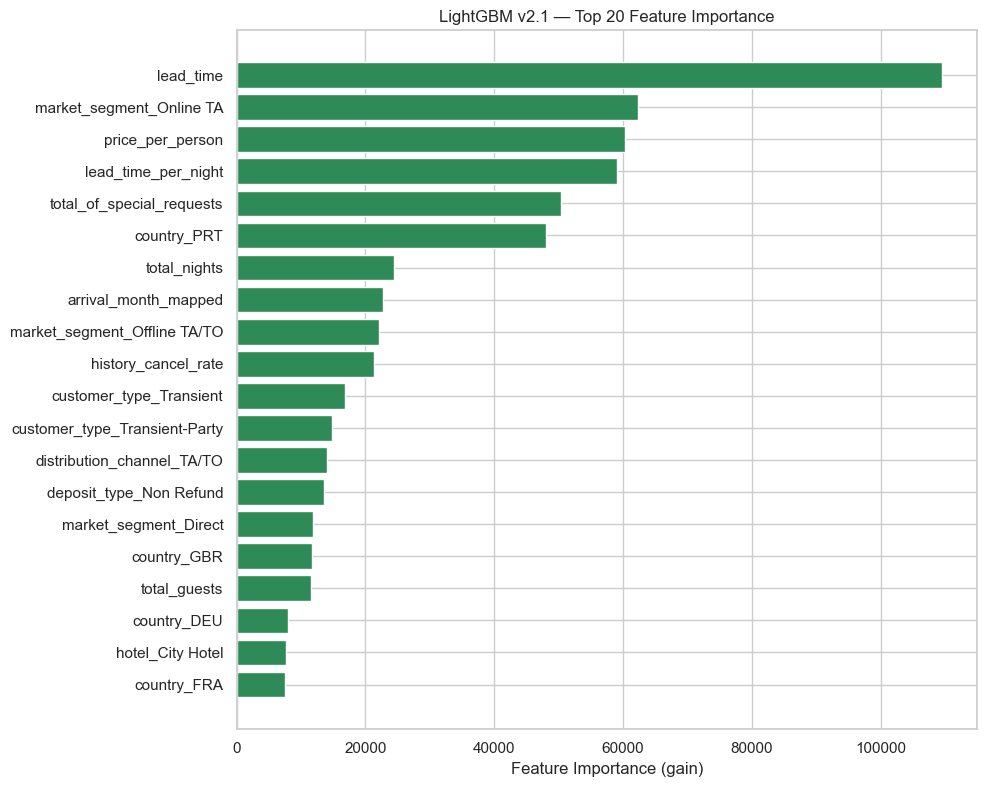


Tổng importance theo biến gốc:


,source,importance
10,lead_time,109461.264628
2,country,103455.583903
12,market_segment,101194.930608
13,price_per_person,60217.457352
11,lead_time_per_night,59123.835333
16,total_of_special_requests,50396.594183
3,customer_type,36609.973499
15,total_nights,24457.497338
0,arrival_month_mapped,22734.640340
5,distribution_channel,22492.555768


In [39]:
preprocessor_fitted = lgbm_pipeline.named_steps["preprocessor"]
cat_encoder = preprocessor_fitted.named_transformers_["cat"]
cat_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES)
feature_names = np.concatenate([cat_names, np.array(NUMERIC_FEATURES, dtype=object)])

classifier = lgbm_pipeline.named_steps["classifier"]
importances = classifier.booster_.feature_importance(importance_type="gain")

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(f"Số cột sau One-Hot Encoding: {len(feature_names)}")
print("\nTop 20 feature quan trọng nhất (gain):")
display(importance_df.head(20))

top_n = 20
plot_df = importance_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["feature"], plot_df["importance"], color="seagreen")
ax.set_xlabel("Feature Importance (gain)")
ax.set_title(f"LightGBM v2.1 — Top {top_n} Feature Importance")
plt.tight_layout()
plt.show()


def map_to_source(feat: str) -> str:
    if feat in NUMERIC_FEATURES:
        return feat
    for cat in CATEGORICAL_FEATURES:
        if feat.startswith(cat + "_"):
            return cat
    return feat.split("_", 1)[0]


importance_df["source"] = importance_df["feature"].map(map_to_source)
grouped = (
    importance_df.groupby("source", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)
print("\nTổng importance theo biến gốc:")
display(grouped)


## 8. SHAP — giải thích biến engineered

`TreeExplainer` trên mẫu test (2.000 quan sát). Biểu đồ gồm:
- Mean |SHAP| theo biến engineered & theo nhóm
- Beeswarm engineered
- **Bổ sung:** SHAP `arrival_season`, dependence plots, beeswarm toàn cục, waterfall 2 ví dụ, bar top 15 toàn cục


In [ ]:
import shap

ENGINEERED_FEATURES = [
    "total_guests",
    "price_per_person",
    "is_family",
    "total_nights",
    "lead_time_per_night",
    "history_cancel_rate",
    "is_weekend_only",
    "arrival_month_mapped",
]
SEASON_OHE_COLS = [c for c in feature_names if str(c).startswith("arrival_season_")]

ENGINEERED_GROUPS = {
    "Financial Commitment": ["total_guests", "price_per_person", "is_family"],
    "Trip Structure": ["total_nights", "lead_time_per_night"],
    "Trust & History": ["history_cancel_rate"],
    "Calendar & Seasonality": ["is_weekend_only", "arrival_month_mapped"],
}
SHAP_SAMPLE_SIZE = 2_000

preprocessor_fitted = lgbm_pipeline.named_steps["preprocessor"]
classifier = lgbm_pipeline.named_steps["classifier"]

X_test_transformed = preprocessor_fitted.transform(X_test)
rng = np.random.default_rng(RANDOM_STATE)
n_shap = min(SHAP_SAMPLE_SIZE, len(X_test))
sample_idx = rng.choice(len(X_test), size=n_shap, replace=False)
X_shap_matrix = X_test_transformed[sample_idx]
y_shap = y_test.iloc[sample_idx].values

explainer = shap.TreeExplainer(classifier)
shap_all = explainer.shap_values(X_shap_matrix)
shap_values = shap_all[:, :, 1] if getattr(shap_all, "ndim", 2) == 3 else shap_all
if isinstance(shap_all, list):
    shap_values = shap_all[1]

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1]

eng_col_idx = [int(np.where(feature_names == f)[0][0]) for f in ENGINEERED_FEATURES]
shap_eng = shap_values[:, eng_col_idx]
X_eng = pd.DataFrame(X_shap_matrix[:, eng_col_idx], columns=ENGINEERED_FEATURES)

feature_to_group = {f: g for g, feats in ENGINEERED_GROUPS.items() for f in feats}

shap_eng_summary = (
    pd.DataFrame(
        {
            "feature": ENGINEERED_FEATURES,
            "mean_abs_shap": np.abs(shap_eng).mean(axis=0),
            "mean_shap": shap_eng.mean(axis=0),
        }
    )
    .assign(group=lambda d: d["feature"].map(feature_to_group))
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("=== Mean |SHAP| — biến engineered (class Hủy) ===")
display(shap_eng_summary.round(5))

if SEASON_OHE_COLS:
    season_idx = [int(np.where(feature_names == c)[0][0]) for c in SEASON_OHE_COLS]
    season_shap = pd.DataFrame(
        {
            "feature": SEASON_OHE_COLS,
            "mean_abs_shap": np.abs(shap_values[:, season_idx]).mean(axis=0),
            "mean_shap": shap_values[:, season_idx].mean(axis=0),
        }
    ).sort_values("mean_abs_shap", ascending=False)
    print("\n=== Mean |SHAP| — arrival_season (One-Hot) ===")
    display(season_shap.round(5))

group_shap = (
    shap_eng_summary.groupby("group", as_index=False)
    .agg(mean_abs_shap=("mean_abs_shap", "sum"), mean_shap=("mean_shap", "sum"))
    .sort_values("mean_abs_shap", ascending=False)
)
print("\n=== Tổng |SHAP| theo nhóm biến ===")
display(group_shap.round(5))

plot_df = shap_eng_summary.sort_values("mean_abs_shap", ascending=True)
colors = plot_df["mean_shap"].apply(lambda v: "#fc8d62" if v > 0 else "#66c2a5")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(plot_df["feature"], plot_df["mean_abs_shap"], color=colors, alpha=0.85)
axes[0].set_xlabel("Mean |SHAP|")
axes[0].set_title("Đóng góp trung bình |SHAP| (biến engineered)")
axes[0].axvline(0, color="black", linewidth=0.8)

group_plot = group_shap.sort_values("mean_abs_shap", ascending=True)
gcolors = group_plot["mean_shap"].apply(lambda v: "#fc8d62" if v > 0 else "#66c2a5")
axes[1].barh(group_plot["group"], group_plot["mean_abs_shap"], color=gcolors, alpha=0.85)
axes[1].set_xlabel("Tổng mean |SHAP|")
axes[1].set_title("Đóng góp theo nhóm feature engineered")
plt.tight_layout()
plt.show()

shap.summary_plot(
    shap_eng,
    X_eng,
    feature_names=ENGINEERED_FEATURES,
    plot_type="dot",
    show=False,
    max_display=len(ENGINEERED_FEATURES),
)
plt.title("SHAP Beeswarm — Biến engineered (màu = giá trị feature)")
plt.tight_layout()
plt.show()


## 8b. SHAP bổ sung — season, dependence, toàn cục, waterfall

Các biểu đồ mở rộng để đọc hướng tác động và giải thích từng booking:
1. **arrival_season** (One-Hot mean |SHAP|)
2. **Dependence plots** cho 4 biến engineered mạnh
3. **Beeswarm toàn cục** top 15
4. **Waterfall** 2 ví dụ (P(hủy) cao / thấp)
5. **Bar mean |SHAP|** top 15 toàn cục


In [ ]:
# --- 1) arrival_season SHAP ---
if SEASON_OHE_COLS:
    season_idx = [int(np.where(feature_names == c)[0][0]) for c in SEASON_OHE_COLS]
    season_plot = (
        pd.DataFrame(
            {
                "feature": SEASON_OHE_COLS,
                "mean_abs_shap": np.abs(shap_values[:, season_idx]).mean(axis=0),
                "mean_shap": shap_values[:, season_idx].mean(axis=0),
            }
        )
        .sort_values("mean_abs_shap", ascending=True)
    )
    fig, ax = plt.subplots(figsize=(9, 4))
    scolors = season_plot["mean_shap"].apply(lambda v: "#fc8d62" if v > 0 else "#66c2a5")
    ax.barh(season_plot["feature"], season_plot["mean_abs_shap"], color=scolors, alpha=0.85)
    ax.set_xlabel("Mean |SHAP|")
    ax.set_title("SHAP — arrival_season (One-Hot)")
    plt.tight_layout()
    plt.show()

# --- 2) Dependence plots ---
top_dep = ["price_per_person", "lead_time_per_night", "history_cancel_rate", "arrival_month_mapped"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, feat in zip(axes.ravel(), top_dep):
    j = ENGINEERED_FEATURES.index(feat)
    sc = ax.scatter(
        X_eng[feat], shap_eng[:, j], c=X_eng[feat], cmap="coolwarm", s=8, alpha=0.45,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel(feat)
    ax.set_ylabel("SHAP value")
    ax.set_title(f"Dependence — {feat}")
plt.tight_layout()
plt.show()

# --- 3) Global beeswarm top 15 ---
shap.summary_plot(
    shap_values,
    X_shap_matrix,
    feature_names=feature_names.tolist(),
    plot_type="dot",
    show=False,
    max_display=15,
)
plt.title("SHAP Beeswarm — Top 15 feature (toàn cục)")
plt.tight_layout()
plt.show()

# --- 4) Waterfall 2 examples ---
sample_proba = classifier.predict_proba(X_shap_matrix)[:, 1]
hi = int(np.argmax(sample_proba))
lo = int(np.argmin(sample_proba))
fig = plt.figure(figsize=(12, 10))
for i, (idx, title) in enumerate([
    (hi, f"Waterfall — P(hủy) cao ({sample_proba[hi]:.2f})"),
    (lo, f"Waterfall — P(hủy) thấp ({sample_proba[lo]:.2f})"),
], start=1):
    ax = fig.add_subplot(2, 1, i)
    exp = shap.Explanation(
        values=shap_values[idx],
        base_values=float(base_value),
        data=X_shap_matrix[idx],
        feature_names=feature_names.tolist(),
    )
    plt.sca(ax)
    shap.plots.waterfall(exp, max_display=12, show=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

# --- 5) Global mean |SHAP| bar top 15 ---
mean_abs = np.abs(shap_values).mean(axis=0)
glob = (
    pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs})
    .sort_values("mean_abs_shap", ascending=False)
    .head(15)
    .iloc[::-1]
)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(glob["feature"], glob["mean_abs_shap"], color="#4c78a8", alpha=0.9)
ax.set_xlabel("Mean |SHAP|")
ax.set_title("SHAP — Top 15 feature toàn cục (mean |SHAP|)")
plt.tight_layout()
plt.show()


## 9. Tóm tắt v2.1

| Tiêu chí | LightGBM v2 | **LightGBM v2.1** |
|----------|-------------|-------------------|
| Thuật toán | `LGBMClassifier` | **Giữ nguyên** |
| Feature | 16 (6 cat + 10 num) | **17** (+ `arrival_season`) |
| Cân bằng lớp | `class_weight='balanced'` | **`scale_pos_weight` × 1,5** |
| Ngưỡng | 0,35 | **0,28** |
| Tuning | GridSearchCV + Optuna | **Giữ nguyên + lưu `best_params` JSON** |

Chạy **Run All** với `RUN_TUNING=True`: ứng viên ghi vào `artifacts/best_params_v2_1_draft.json`, chỉ promote sang `best_params_v2_1.json` nếu CV ROC-AUC tốt hơn. Đổi `TUNING_SEED` để Optuna tìm vùng khác. Đặt `RUN_TUNING=False` để nạp production.
